In [1]:
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

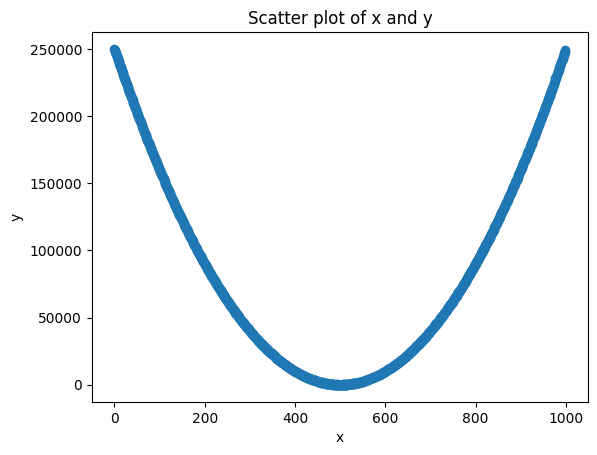

In [2]:
x = list(range(1000))
#y = [2*i + np.random.normal(0, i/4) for i in x]
y = [(i-500)**2 + np.random.normal(0, i/4) for i in x]

df = pd.DataFrame({'x': x, 'y': y})
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
plt.show()

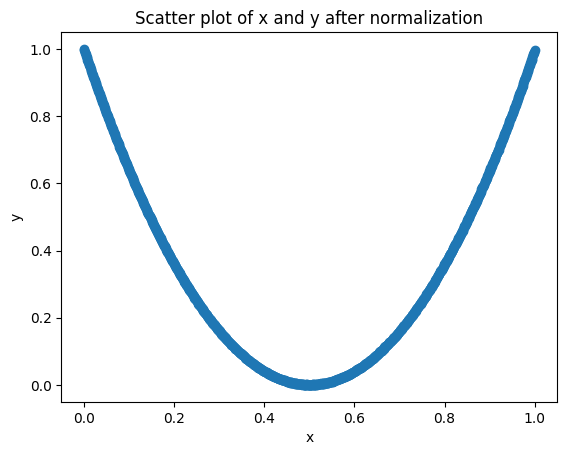

In [3]:
# normalize the data min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
plt.scatter(df['x'], df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after normalization')
plt.show()

In [4]:
x_train = df[['x', 'y']].values
x_train.shape

(1000, 2)

In [5]:
x_train

array([[0.        , 1.        ],
       [0.001001  , 0.99600705],
       [0.002002  , 0.99201753],
       ...,
       [0.997998  , 0.98810048],
       [0.998999  , 0.99056331],
       [1.        , 0.99589668]], shape=(1000, 2))

In [7]:
import keras

In [8]:
input_shape = (2,)
encoder = keras.models.Sequential([keras.layers.Dense(1)]) 
# if activaton is not defined, it is linear by default
decoder = keras.models.Sequential([keras.layers.Dense(input_shape[0])])

autoencoder = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        encoder, 
        decoder
])
autoencoder.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
autoencoder.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=0.01))
history = autoencoder.fit(x_train, x_train, epochs=100)
codings = encoder.predict(x_train)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0606  
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0591 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0577 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0564 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0552 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0541 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0530 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0521 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0512 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0504 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0497 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0490 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0483 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0477 
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [12]:
T = codings
print(T)
print(T.shape)


[[ 8.02836597e-01]
 [ 7.98219621e-01]
 [ 7.93606818e-01]
 [ 7.89013684e-01]
 [ 7.84415543e-01]
 [ 7.79848397e-01]
 [ 7.75276959e-01]
 [ 7.70731151e-01]
 [ 7.66163647e-01]
 [ 7.61619508e-01]
 [ 7.57102311e-01]
 [ 7.52568424e-01]
 [ 7.48070776e-01]
 [ 7.43528903e-01]
 [ 7.39093721e-01]
 [ 7.34587014e-01]
 [ 7.30128586e-01]
 [ 7.25642741e-01]
 [ 7.21240580e-01]
 [ 7.16767251e-01]
 [ 7.12330997e-01]
 [ 7.07881033e-01]
 [ 7.03460991e-01]
 [ 6.99077189e-01]
 [ 6.94691718e-01]
 [ 6.90285146e-01]
 [ 6.86004817e-01]
 [ 6.81606948e-01]
 [ 6.77254617e-01]
 [ 6.72864020e-01]
 [ 6.68552935e-01]
 [ 6.64270341e-01]
 [ 6.59851611e-01]
 [ 6.55539930e-01]
 [ 6.51335180e-01]
 [ 6.46981657e-01]
 [ 6.42697275e-01]
 [ 6.38433516e-01]
 [ 6.34203136e-01]
 [ 6.29945815e-01]
 [ 6.25736654e-01]
 [ 6.21450961e-01]
 [ 6.17244065e-01]
 [ 6.13087833e-01]
 [ 6.08823001e-01]
 [ 6.04727685e-01]
 [ 6.00415170e-01]
 [ 5.96238077e-01]
 [ 5.92128813e-01]
 [ 5.87933362e-01]
 [ 5.83871841e-01]
 [ 5.79783499e-01]
 [ 5.7559412

In [13]:
newdf = decoder.predict(T)
newdf

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[0.59873354, 0.8806782 ],
       [0.5980597 , 0.8770221 ],
       [0.5973864 , 0.8733694 ],
       ...,
       [0.6316558 , 1.0592965 ],
       [0.6321283 , 1.0618598 ],
       [0.6331104 , 1.0671884 ]], shape=(1000, 2), dtype=float32)

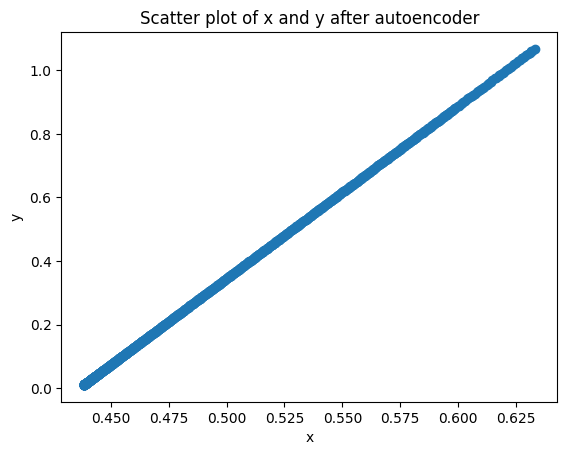

In [14]:
plt.scatter(newdf[:, 0], newdf[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y after autoencoder')
plt.show()